In [1]:
import pandas as pd
import sys
sys.path.append('..')  # Si estás en notebooks/

from src.data.data_quality import analyze_data_quality, show_categorical_columns    

In [2]:
import pandas as pd
df_train = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_train.parquet", engine="pyarrow")
df_test = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_test.parquet", engine="pyarrow")
df_oot = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_oot.parquet", engine="pyarrow")
df_oos = pd.read_parquet("C:/Users/carlo/OneDrive/Documentos/repos/meli-ds/data/processed/df_oos.parquet", engine="pyarrow")

In [84]:
df_train.shape

(80933, 125)

In [85]:
df_test.shape

(10891, 125)

In [86]:
df_oot.shape

(4005, 125)

In [87]:
df_oos.shape

(11782, 125)

In [3]:
varss=['attribute1',
 'attribute4',
 'attribute1_lag_15_std',
 'attribute1_lag_90_min',
 'attribute6_lag_7_std',
 'attribute6_lag_15_std',
 'attribute4_cumulative_change',
 'attribute7_change_rate',
 'attribute1_lag_30_std',
 'attribute6_lag_90_std',
 'attribute6_lag_120_std',
 'attribute6',
 'attribute1_lag_7_max',
 'attribute1_lag_15_min',
 'attribute1_lag_30_min',
 'attribute1_lag_60_min',
 'attribute1_lag_60_max',
 'attribute5_lag_120_min',
 'attribute6_lag_15_mean',
 'attribute6_lag_30_mean',
 'attribute6_lag_30_std',
 'attribute6_lag_60_std',
 'attribute4_change_rate']

In [83]:
x_train.shape

(80933, 23)

In [5]:
# Imputar NaN a -999 en variables específicas
import numpy as np
target_vars = ['attribute4_change_rate', 'attribute4_cumulative_change', 
               'attribute7_change_rate']

for var in target_vars:
    df_train[var] = df_train[var].fillna(-999)
    df_test[var] = df_test[var].fillna(-999)
    df_oot[var] = df_oot[var].fillna(-999)
    df_oos[var] = df_oos[var].fillna(-999)

# Imputar infinitos a -999
for var in target_vars:
    df_train[var] = df_train[var].replace([np.inf, -np.inf], -999)
    df_test[var] = df_test[var].replace([np.inf, -np.inf], -999)
    df_oot[var] = df_oot[var].replace([np.inf, -np.inf], -999)
    df_oos[var] = df_oos[var].replace([np.inf, -np.inf], -999)

print("✅ Imputación completada")

✅ Imputación completada


In [6]:
x_train = df_train[varss].copy()
y_train = df_train['failure'].copy()

x_test = df_test[varss]
y_test = df_test['failure']

x_oot = df_oot[varss].copy()
y_oot = df_oot['failure'].copy()

x_oos = df_oos[varss].copy()
y_oos = df_oos['failure'].copy()

In [89]:
y_oot.value_counts()

failure
0    4003
1       2
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import RobustScaler

# Crear scaler
scaler = RobustScaler()

# Ajustar con datos de entrenamiento
scaler.fit(x_train)

# Escalar todos los datasets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_oot_scaled = scaler.transform(x_oot)
x_oos_scaled = scaler.transform(x_oos)


In [ ]:
# Celda 1: Imports y configuración base
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    fbeta_score, precision_score, recall_score, confusion_matrix,
    average_precision_score, make_scorer, precision_recall_curve
)
from imblearn.combine import SMOTETomek

# Modelos
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Configuración global
RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 20
BETA = 2.0        # F2 para priorizar recall
C_FN = 10000.0    # costo por no detectar falla
C_FP = 1000.0      # costo por falsa alarma

print("✅ Configuración lista")


✅ Configuración lista


In [12]:
from collections import Counter
import numpy as np

f_obj = 0.10  # proporción deseada minoría (10%)
counter = Counter(y_train)
m, M = counter[1], counter[0]

print("Distribución original:", counter)
sampling_ratio_smote = (f_obj / (1 - f_obj))  # proporción minoría/mayoría para SMOTE
print(f"Sampling ratio SMOTE-Tomek: {sampling_ratio_smote:.4f}")


Distribución original: Counter({0: 80846, 1: 87})
Sampling ratio SMOTE-Tomek: 0.1111


In [13]:
from imblearn.combine import SMOTETomek

# Configuración del rebalanceo híbrido controlado
smote_tomek = SMOTETomek(sampling_strategy=sampling_ratio_smote, random_state=42, n_jobs=-1)

X_train_res, y_train_res = smote_tomek.fit_resample(x_train_scaled, y_train)

from collections import Counter
print("Después de SMOTE-Tomek:", Counter(y_train_res))


Después de SMOTE-Tomek: Counter({0: 80846, 1: 8982})


In [14]:
y_train_res.value_counts()

failure
0    80846
1     8982
Name: count, dtype: int64

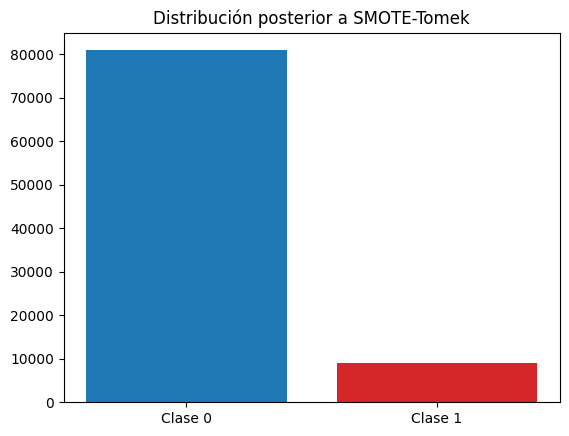

In [15]:
import matplotlib.pyplot as plt
counts = Counter(y_train_res)
plt.bar(counts.keys(), counts.values(), color=['#1f77b4', '#d62728'])
plt.xticks([0, 1], ['Clase 0', 'Clase 1'])
plt.title('Distribución posterior a SMOTE-Tomek')
plt.show()


In [37]:
# Celda A: Imports y pos_weight base
import numpy as np
import optuna
from sklearn.metrics import fbeta_score
from collections import Counter

# calcula pos_weight sobre el train rebalanceado (si ya lo generaste)
# si aún no: ejecuta la celda de rebalanceo previamente para obtener X_train_res, y_train_res
pos_weight = (y_train_res == 0).sum() / max((y_train_res == 1).sum(), 1)
print("pos_weight (train rebalanceado) =", pos_weight)


pos_weight (train rebalanceado) = 9.000890670229348


In [ ]:

fbeta_scorer = make_scorer(fbeta_score, beta=BETA, pos_label=1)

def find_best_threshold_by_cost(y_true, y_proba, C_FN=C_FN, C_FP=C_FP):
    """Encuentra umbral óptimo que minimiza el costo esperado."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    P = (y_true == 1).sum()
    TP = rec * P
    FN = P - TP
    FP = (TP / (prec + 1e-12)) - TP
    cost = C_FN * FN + C_FP * FP
    idx = np.nanargmin(cost)
    best_thr = thr[idx] if idx < len(thr) else 0.5
    return best_thr, cost[idx], prec[idx], rec[idx]

def eval_at_threshold(y_true, y_proba, thr, beta=BETA):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        f"F{beta}": fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "cost": C_FN * fn + C_FP * fp,
        "AUC-PR": average_precision_score(y_true, y_proba)
    }


In [65]:
# Celda B: Optuna objective para LightGBM (evalúa en x_test_scaled)
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42
N_TRIALS = 100
BETA = 2.0

def objective_lgb_on_test(trial):
    # rango de scale_pos_weight alrededor del ratio calculado (log scale)
    spw_low = max(1.0, pos_weight / 10.0)
    spw_high = max(spw_low * 10.0, pos_weight * 10.0)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 80),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 150.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 150.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", spw_low, spw_high, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)
    # entrenar sobre X_train_res (rebalanceado)
    model.fit(X_train_res, y_train_res)

    # evaluar en hold-out x_test_scaled
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.8).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=BETA, zero_division=0)
    return f2

study_lgb = optuna.create_study(direction="maximize", study_name="LGB_on_test_F2")
study_lgb.optimize(objective_lgb_on_test, n_trials=100, show_progress_bar=True)

print("LightGBM best F2 (on test):", study_lgb.best_value)
print("LightGBM best params:", study_lgb.best_params)

[I 2025-10-08 23:29:48,542] A new study created in memory with name: LGB_on_test_F2


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-10-08 23:29:49,919] Trial 0 finished with value: 0.08771929824561403 and parameters: {'n_estimators': 224, 'max_depth': 17, 'num_leaves': 41, 'learning_rate': 0.05183631741007696, 'min_child_samples': 60, 'reg_alpha': 103.95497927743432, 'reg_lambda': 100.11110577969175, 'scale_pos_weight': 1.664153894448734}. Best is trial 0 with value: 0.08771929824561403.


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[I 2025-10-08 23:31:33,623] Trial 97 finished with value: 0.24096385542168675 and parameters: {'n_estimators': 114, 'max_depth': 17, 'num_leaves': 22, 'learning_rate': 0.06742283489514467, 'min_child_samples': 37, 'reg_alpha': 46.69954016641002, 'reg_lambda': 25.447680447368537, 'scale_pos_weight': 5.375475561036343}. Best is trial 88 with value: 0.3225806451612903.


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-10-08 23:31:34,591] Trial 98 finished with value: 0.30303030303030304 and parameters: {'n_estimators': 95, 'max_depth': 18, 'num_leaves': 19, 'learning_rate': 0.08163725291486668, 'min_child_samples': 44, 'reg_alpha': 78.05140641494347, 'reg_lambda': 29.536848233579086, 'scale_pos_weight': 6.451829174417181}. Best is trial 88 with value: 0.3225806451612903.


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2025-10-08 23:31:35,336] Trial 99 finished with value: 0.21428571428571427 and parameters: {'n_estimators': 94, 'max_depth': 17, 'num_leaves': 16, 'learning_rate': 0.07887778442771007, 'min_child_samples': 43, 'reg_alpha': 79.05114697846803, 'reg_lambda': 19.396687968353245, 'scale_pos_weight': 7.7741701533847705}. Best is trial 88 with value: 0.3225806451612903.
LightGBM best F2 (on test): 0.3225806451612903
LightGBM best params: {'n_estimators': 84, 'max_depth': 18, 'num_leaves': 21, 'learning_rate': 0.07454681453778898, 'min_child_samples': 40, 'reg_alpha': 57.687354287016355, 'reg_lambda': 34.642904652301446, 'scale_pos_weight': 5.34313019528808}


In [50]:
# Celda C: Optuna objective para CatBoost (evalúa en x_test_scaled)
from catboost import CatBoostClassifier

def objective_cat_on_test(trial):
    spw_low = max(1.0, pos_weight / 10.0)
    spw_high = max(spw_low * 10.0, pos_weight * 10.0)

    # CatBoost usa class_weights (lista) en lugar de scale_pos_weight en algunas versiones
    scale_pos = trial.suggest_float("scale_pos_weight", spw_low, spw_high, log=True)
    class_weights = [1.0, float(scale_pos)]

    params = {
        "iterations": trial.suggest_int("iterations", 50, 250),
        "depth": trial.suggest_int("depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 150.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "verbose": 0,
        "class_weights": class_weights
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train_res, y_train_res)

    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=BETA, zero_division=0)
    return f2

study_cat = optuna.create_study(direction="maximize", study_name="Cat_on_test_F2")
study_cat.optimize(objective_cat_on_test, n_trials=20, show_progress_bar=True)

print("CatBoost best F2 (on test):", study_cat.best_value)
print("CatBoost best params:", study_cat.best_params)


[I 2025-10-08 23:05:47,761] A new study created in memory with name: Cat_on_test_F2


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-10-08 23:05:51,336] Trial 0 finished with value: 0.01891891891891892 and parameters: {'scale_pos_weight': 44.536737308395786, 'iterations': 118, 'depth': 6, 'learning_rate': 0.018145764186983614, 'l2_leaf_reg': 0.0024785938900522384, 'bagging_temperature': 0.344654161960702}. Best is trial 0 with value: 0.01891891891891892.
[I 2025-10-08 23:05:55,869] Trial 1 finished with value: 0.10574018126888217 and parameters: {'scale_pos_weight': 16.45624113537632, 'iterations': 233, 'depth': 4, 'learning_rate': 0.0639920627941076, 'l2_leaf_reg': 1.2163508578341407, 'bagging_temperature': 0.7952830642098664}. Best is trial 1 with value: 0.10574018126888217.
[I 2025-10-08 23:05:58,252] Trial 2 finished with value: 0.05672609400324149 and parameters: {'scale_pos_weight': 21.585229172540224, 'iterations': 88, 'depth': 5, 'learning_rate': 0.07618278983521509, 'l2_leaf_reg': 0.7546095030723905, 'bagging_temperature': 0.6289795254410109}. Best is trial 1 with value: 0.10574018126888217.
[I 2025

In [59]:
# Celda C corregida: Optuna objective para CatBoost optimizando AUC-PR
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

def objective_cat_on_test_pr_auc(trial):
    spw_low = max(1.0, pos_weight / 10.0)
    spw_high = max(spw_low * 10.0, pos_weight * 10.0)

    # CatBoost usa class_weights (lista) en lugar de scale_pos_weight
    scale_pos = trial.suggest_float("scale_pos_weight", spw_low, spw_high, log=True)
    class_weights = [1.0, float(scale_pos)]

    params = {
        "iterations": trial.suggest_int("iterations", 50, 250),
        "depth": trial.suggest_int("depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 150.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "verbose": 0,
        "class_weights": class_weights
    }

    # Entrenamos en train rebalanceado
    model = CatBoostClassifier(**params)
    model.fit(X_train_res, y_train_res)

    # Evaluamos en test
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    pr_auc = average_precision_score(y_test, y_proba)

    return pr_auc  # <- optimizamos PR-AUC, no F2

# Estudio Optuna
study_cat_pr_auc = optuna.create_study(direction="maximize", study_name="Cat_on_test_PRAUC")
study_cat_pr_auc.optimize(objective_cat_on_test_pr_auc, n_trials=100, show_progress_bar=True)

print("CatBoost best PR-AUC (on test):", study_cat_pr_auc.best_value)
print("CatBoost best params:", study_cat_pr_auc.best_params)


[I 2025-10-08 23:18:01,280] A new study created in memory with name: Cat_on_test_PRAUC


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-08 23:18:03,293] Trial 0 finished with value: 0.1809496331060226 and parameters: {'scale_pos_weight': 5.302039300503061, 'iterations': 63, 'depth': 4, 'learning_rate': 0.058809739958150975, 'l2_leaf_reg': 7.235519951446729, 'bagging_temperature': 0.6306961453117125}. Best is trial 0 with value: 0.1809496331060226.
[I 2025-10-08 23:18:07,996] Trial 1 finished with value: 0.10921085601387327 and parameters: {'scale_pos_weight': 47.94539906033603, 'iterations': 205, 'depth': 5, 'learning_rate': 0.060698194139768166, 'l2_leaf_reg': 0.03383669539983255, 'bagging_temperature': 0.5449128294161788}. Best is trial 0 with value: 0.1809496331060226.
[I 2025-10-08 23:18:16,957] Trial 2 finished with value: 0.0408307655686139 and parameters: {'scale_pos_weight': 3.401891145175741, 'iterations': 230, 'depth': 8, 'learning_rate': 0.03422203467676363, 'l2_leaf_reg': 0.028866213315738784, 'bagging_temperature': 0.8620193232080151}. Best is trial 0 with value: 0.1809496331060226.
[I 2025-10-0

In [75]:
# Celda D: Optuna objective para HistGradientBoostingClassifier (evalúa en x_test_scaled)
from sklearn.ensemble import HistGradientBoostingClassifier

def objective_hgb_on_test(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 50, 250),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 55),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 80),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 120.0),
        "random_state": RANDOM_STATE,
        # usar class_weight balanced para que maneje el desbalance
        "class_weight": "balanced"
    }
    model = HistGradientBoostingClassifier(**params)
    model.fit(X_train_res, y_train_res)

    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.8).astype(int)
    f2 = fbeta_score(y_test, y_pred, beta=BETA, zero_division=0)
    return f2

study_hgb = optuna.create_study(direction="maximize", study_name="HGB_on_test_F2")
study_hgb.optimize(objective_hgb_on_test, n_trials=N_TRIALS, show_progress_bar=True)

print("HistGB best F2 (on test):", study_hgb.best_value)
print("HistGB best params:", study_hgb.best_params)


[I 2025-10-08 23:38:34,708] A new study created in memory with name: HGB_on_test_F2


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-08 23:38:37,563] Trial 0 finished with value: 0.14150943396226415 and parameters: {'max_iter': 115, 'max_leaf_nodes': 43, 'learning_rate': 0.014147279318975591, 'max_depth': 11, 'min_samples_leaf': 10, 'l2_regularization': 7.6939485131124785}. Best is trial 0 with value: 0.14150943396226415.
[I 2025-10-08 23:38:38,790] Trial 1 finished with value: 0.14285714285714285 and parameters: {'max_iter': 148, 'max_leaf_nodes': 13, 'learning_rate': 0.04550482026735089, 'max_depth': 3, 'min_samples_leaf': 78, 'l2_regularization': 73.12609282949369}. Best is trial 1 with value: 0.14285714285714285.
[I 2025-10-08 23:38:39,587] Trial 2 finished with value: 0.12738853503184713 and parameters: {'max_iter': 51, 'max_leaf_nodes': 23, 'learning_rate': 0.03589614084570545, 'max_depth': 11, 'min_samples_leaf': 41, 'l2_regularization': 25.308361262007505}. Best is trial 1 with value: 0.14285714285714285.
[I 2025-10-08 23:38:41,341] Trial 3 finished with value: 0.13513513513513514 and parameters: 

In [76]:
#Entrenar modelos finales con mejores hiperparámetros
best_lgb = LGBMClassifier(**study_lgb.best_params, random_state=RANDOM_STATE)
best_cat = CatBoostClassifier(**study_cat.best_params, random_state=RANDOM_STATE, verbose=False)
best_hgb = HistGradientBoostingClassifier(**study_hgb.best_params, random_state=RANDOM_STATE)

best_lgb.fit(X_train_res, y_train_res)
best_cat.fit(X_train_res, y_train_res)
best_hgb.fit(X_train_res, y_train_res)

models = {"LightGBM": best_lgb, "CatBoost": best_cat, "HistGB": best_hgb}
print("✅ Modelos entrenados")


✅ Modelos entrenados


In [77]:
# Celda 8: Evaluación con umbral óptimo
datasets = {
    
    "Train_original": (x_train_scaled, y_train),
    "Test": (x_test_scaled, y_test),
    "Val": (x_val_scaled, y_val)
}

results = []
for name, model in models.items():
    y_proba_test = model.predict_proba(x_test_scaled)[:, 1]
    best_thr, best_cost, best_prec, best_rec = find_best_threshold_by_cost(y_test, y_proba_test)
    print(f"\n{name} → Umbral óptimo: {best_thr:.4f} | Costo: {best_cost:,.0f}")
    
    for dname, (X_d, y_d) in datasets.items():
        y_proba = model.predict_proba(X_d)[:, 1]
        metrics = eval_at_threshold(y_d, y_proba, best_thr, beta=BETA)
        metrics.update({"modelo": name, "dataset": dname, "thr": best_thr})
        results.append(metrics)

results_df = pd.DataFrame(results)
display(results_df)


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM → Umbral óptimo: 0.8159 | Costo: 91,000


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



CatBoost → Umbral óptimo: 0.5166 | Costo: 99,000

HistGB → Umbral óptimo: 0.6024 | Costo: 103,000


,precision,recall,F2.0,TP,FP,FN,TN,cost,AUC-PR,modelo,dataset,thr
0,0.145270,0.494253,0.333851,43,253,44,80593,693000.0,0.207177,LightGBM,Train_original,0.815878
1,0.127660,0.545455,0.329670,6,41,5,10839,91000.0,0.156991,LightGBM,Test,0.815878
2,0.006689,0.285714,0.030581,2,297,5,15483,347000.0,0.039342,LightGBM,Val,0.815878
3,0.508475,0.689655,0.643777,60,58,27,80788,328000.0,0.625871,CatBoost,Train_original,0.516608
4,0.121212,0.363636,0.259740,4,29,7,10851,99000.0,0.067436,CatBoost,Test,0.516608
5,0.009259,0.142857,0.036765,1,107,6,15673,167000.0,0.009202,CatBoost,Val,0.516608
6,0.319328,0.436782,0.406852,38,81,49,80765,571000.0,0.335144,HistGB,Train_original,0.602402
7,0.133333,0.181818,0.169492,2,13,9,10867,103000.0,0.032135,HistGB,Test,0.602402
8,0.008065,0.142857,0.032895,1,123,6,15657,183000.0,0.005613,HistGB,Val,0.602402


In [51]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, fbeta_score, average_precision_score, confusion_matrix
import pandas as pd
import numpy as np

def evaluate_model(model, X, y, dataset_name, model_name, C_FN=10000, C_FP=100):
    """
    Evalúa un modelo binario en un dataset con métricas y costo esperado.

    Parámetros:
    ------------
    model : modelo entrenado (con método predict_proba)
    X : features
    y : etiquetas reales
    dataset_name : str ("Train", "Test", "OOT", "OOS", etc.)
    model_name : str ("CatBoost", "LightGBM", etc.)
    C_FN : costo por falso negativo
    C_FP : costo por falso positivo

    Retorna:
    --------
    pd.DataFrame con métricas estandarizadas.
    """

    # Probabilidades de clase positiva
    y_proba = model.predict_proba(X)[:, 1]

    # Curva precisión-recall para obtener umbral óptimo
    prec, rec, thr = precision_recall_curve(y, y_proba)
    P = (y == 1).sum()
    TP = rec * P
    FN = P - TP
    FP = (TP / (prec + 1e-12)) - TP
    cost_expected = C_FN * FN + C_FP * FP

    # Buscar umbral óptimo (mínimo costo esperado)
    idx_min = np.nanargmin(cost_expected)
    best_thr = thr[idx_min] if idx_min < len(thr) else 0.5

    # Predicciones binarizadas con el umbral óptimo
    y_pred = (y_proba >= best_thr).astype(int)

    # Métricas principales
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred)
    f2 = fbeta_score(y, y_pred, beta=2)
    auc_pr = average_precision_score(y, y_proba)
    cost_min = cost_expected[idx_min]

    # Matriz de confusión (opcional)
    cm = confusion_matrix(y, y_pred)

    print(f"\n📊 Evaluación {model_name} ({dataset_name})")
    print(f"Umbral óptimo: {best_thr:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F2: {f2:.4f}")
    print(f"AUC-PR: {auc_pr:.4f} | Costo esperado: {cost_min:,.2f}")
    print("Matriz de confusión:")
    print(pd.DataFrame(cm, index=["No Falla (0)", "Falla (1)"], columns=["Pred 0", "Pred 1"]))

    # Resultado estructurado
    result = pd.DataFrame([{
        "modelo": model_name,
        "dataset": dataset_name,
        "precision": precision,
        "recall": recall,
        "F2": f2,
        "AUC-PR": auc_pr,
        "cost": cost_min,
        "umbral_optimo": best_thr
    }])

    return result


In [33]:
# Concatenar x_oot_scaled y x_oos_scaled
x_val_scaled = np.concatenate([x_oot_scaled, x_oos_scaled], axis=0)

# Concatenar y_oot y y_oos
y_val = np.concatenate([y_oot, y_oos], axis=0)

print("✅ Concatenación completada")

✅ Concatenación completada


In [90]:
# Ejemplo: evaluar un modelo entrenado (por ejemplo best_model_catboost)
results = []

for X, y, name in [
    (x_train_scaled, y_train, "Train"),
    (x_test_scaled, y_test, "Test"),
    (x_val_scaled, y_val, "Val")
]:
    results.append(
        evaluate_model(best_hgb, X, y, dataset_name=name, model_name="CatBoost")
    )

results_df = pd.concat(results, ignore_index=True)



📊 Evaluación CatBoost (Train)
Umbral óptimo: 0.1766
Precision: 0.0978 | Recall: 0.8046 | F2: 0.3289
AUC-PR: 0.3351 | Costo esperado: 234,600.00
Matriz de confusión:
              Pred 0  Pred 1
No Falla (0)   80200     646
Falla (1)         17      70

📊 Evaluación CatBoost (Test)
Umbral óptimo: 0.2384
Precision: 0.0325 | Recall: 0.3636 | F2: 0.1198
AUC-PR: 0.0321 | Costo esperado: 81,900.00
Matriz de confusión:
              Pred 0  Pred 1
No Falla (0)   10761     119
Falla (1)          7       4

📊 Evaluación CatBoost (Val)
Umbral óptimo: 0.8141
Precision: 0.0227 | Recall: 0.1429 | F2: 0.0694
AUC-PR: 0.0056 | Costo esperado: 64,300.00
Matriz de confusión:
              Pred 0  Pred 1
No Falla (0)   15737      43
Falla (1)          6       1


In [32]:
y_oos.value_counts()

failure
0    11777
1        5
Name: count, dtype: int64

In [71]:
# Feature importance del mejor CatBoost
feature_importance = best_cat.get_feature_importance()

# Crear DataFrame con importancia
importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

                         feature  importance
13         attribute1_lag_15_min    7.349424
6   attribute4_cumulative_change    6.780294
20         attribute6_lag_30_std    6.075022
12          attribute1_lag_7_max    5.715175
2          attribute1_lag_15_std    5.330398
14         attribute1_lag_30_min    5.318772
10        attribute6_lag_120_std    4.897582
5          attribute6_lag_15_std    4.836039
0                     attribute1    4.772848
16         attribute1_lag_60_max    4.689895
8          attribute1_lag_30_std    4.096714
15         attribute1_lag_60_min    3.979665
19        attribute6_lag_30_mean    3.970530
18        attribute6_lag_15_mean    3.957372
11                    attribute6    3.864120
4           attribute6_lag_7_std    3.750473
7         attribute7_change_rate    3.731539
9          attribute6_lag_90_std    3.536051
17        attribute5_lag_120_min    3.488552
3          attribute1_lag_90_min    3.433901


In [73]:
# Feature importance del mejor LightGBM
feature_importance = best_lgb.feature_importances_

# Crear DataFrame con importancia
importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

                         feature  importance
17        attribute5_lag_120_min         264
10        attribute6_lag_120_std         127
4           attribute6_lag_7_std          99
12          attribute1_lag_7_max          95
14         attribute1_lag_30_min          92
16         attribute1_lag_60_max          85
22        attribute4_change_rate          79
7         attribute7_change_rate          73
5          attribute6_lag_15_std          71
20         attribute6_lag_30_std          65
13         attribute1_lag_15_min          64
0                     attribute1          64
9          attribute6_lag_90_std          63
2          attribute1_lag_15_std          58
6   attribute4_cumulative_change          57
3          attribute1_lag_90_min          55
11                    attribute6          49
21         attribute6_lag_60_std          46
8          attribute1_lag_30_std          38
19        attribute6_lag_30_mean          37


In [82]:
from sklearn.inspection import permutation_importance

# Calcular permutation importance
perm_importance = permutation_importance(
    best_hgb,           # Tu modelo entrenado
    x_test,              # Datos de test
    y_test,              # Target de test
    n_repeats=10,        # Repeticiones para estabilidad
    random_state=42
)

# Crear DataFrame
importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:

                         feature  importance  std
0                     attribute1         0.0  0.0
12          attribute1_lag_7_max         0.0  0.0
21         attribute6_lag_60_std         0.0  0.0
20         attribute6_lag_30_std         0.0  0.0
19        attribute6_lag_30_mean         0.0  0.0
18        attribute6_lag_15_mean         0.0  0.0
17        attribute5_lag_120_min         0.0  0.0
16         attribute1_lag_60_max         0.0  0.0
15         attribute1_lag_60_min         0.0  0.0
14         attribute1_lag_30_min         0.0  0.0
13         attribute1_lag_15_min         0.0  0.0
11                    attribute6         0.0  0.0
1                     attribute4         0.0  0.0
10        attribute6_lag_120_std         0.0  0.0
9          attribute6_lag_90_std         0.0  0.0
8          attribute1_lag_30_std         0.0  0.0
7         attribute7_change_rate         0.0  0.0
6   attribute4_cumulative_change         0.0  0.0
5          attribute6_lag_15_std         0.0  0.0


c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\carlo\OneDrive\Documentos\repos\meli-ds\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [94]:
import joblib
import os

# Crear directorio si no existe
os.makedirs('models/production', exist_ok=True)

# Guardar el mejor CatBoost
joblib.dump(best_cat, 'models/production/best_catboost.sav')

print("✅ CatBoost guardado en models/production/best_catboost.sav")

✅ CatBoost guardado en models/production/best_catboost.sav
